# 🧹 Notebook 2 — Data Cleaning & Preprocessing
Melakukan pembersihan data, imputasi, encoding, scaling, dan penanganan imbalanced dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../dataset/agro_environmental_dataset.csv')
print("Shape awal:", df.shape)
df.head()


Shape awal: (543210, 25)


,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


## 1. Drop Kolom ID (tidak relevan untuk model)

In [2]:
df = df.drop(columns=['location_id'])
print("Shape setelah drop location_id:", df.shape)
print("Kolom tersisa:", df.columns.tolist())


Shape setelah drop location_id: (543210, 24)
Kolom tersisa: ['soil_type', 'bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'moisture_regime', 'soil_temp_c', 'air_temp_c', 'thermal_regime', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'nutrient_balance', 'plant_category', 'suitability_score', 'stress_level', 'failure_flag']


## 2. Hapus Baris Duplikat

In [3]:
dup_count = df.duplicated().sum()
print(f"Baris duplikat sebelum: {dup_count}")
df = df.drop_duplicates()
print(f"Shape setelah remove duplikat: {df.shape}")


Baris duplikat sebelum: 0
Shape setelah remove duplikat: (543210, 24)


## 3. Imputasi Missing Values

In [4]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values")

# Imputasi numerik dengan median, kategorikal dengan modus
num_cols = df.select_dtypes(include='number').columns.drop('failure_flag').tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Imputasi median: {col}")

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  Imputasi modus: {col}")

print("Missing values setelah imputasi:", df.isnull().sum().sum())


=== Missing Values ===
Tidak ada missing values
Missing values setelah imputasi: 0


## 4. Encoding Fitur Kategorikal

In [5]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print("Kolom kategorikal yang akan di-encode:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"  Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nShape setelah encoding:", df.shape)


Kolom kategorikal yang akan di-encode: ['soil_type', 'moisture_regime', 'thermal_regime', 'nutrient_balance', 'plant_category']
  Encoded 'soil_type': {'Alluvial': np.int64(0), 'Chalky': np.int64(1), 'Clayey': np.int64(2), 'Laterite': np.int64(3), 'Loamy': np.int64(4), 'Peaty': np.int64(5), 'Saline': np.int64(6), 'Sandy': np.int64(7), 'Silty': np.int64(8)}
  Encoded 'moisture_regime': {'dry': np.int64(0), 'optimal': np.int64(1), 'waterlogged': np.int64(2)}
  Encoded 'thermal_regime': {'cold': np.int64(0), 'heat_stress': np.int64(1), 'optimal': np.int64(2)}
  Encoded 'nutrient_balance': {'deficient': np.int64(0), 'excessive': np.int64(1), 'optimal': np.int64(2)}
  Encoded 'plant_category': {'cereal': np.int64(0), 'legume': np.int64(1), 'vegetable': np.int64(2)}

Shape setelah encoding: (543210, 24)


## 5. Pemilihan Fitur Berdasarkan Korelasi

In [6]:
corr = df.corr()['failure_flag'].drop('failure_flag').abs().sort_values(ascending=False)
print("=== Korelasi Fitur terhadap Target ===")
print(corr.round(4))

# Ambil fitur dengan korelasi >= 0.02 (threshold minimal)
threshold = 0.02
selected_features = corr[corr >= threshold].index.tolist()
print(f"\nFitur yang dipilih (korelasi >= {threshold}): {selected_features}")
print(f"Jumlah fitur terpilih: {len(selected_features)}")


=== Korelasi Fitur terhadap Target ===
suitability_score           0.6458
stress_level                0.6036
ph_stress_flag              0.5521
thermal_regime              0.2414
soil_temp_c                 0.2164
moisture_regime             0.2049
air_temp_c                  0.2010
nutrient_balance            0.1690
soil_moisture_pct           0.1370
moisture_limit_dry          0.1280
salinity_ec                 0.1168
moisture_limit_wet          0.1120
buffering_capacity          0.1090
soil_ph                     0.0991
cation_exchange_capacity    0.0977
bulk_density                0.0848
soil_type                   0.0810
organic_matter_pct          0.0696
phosphorus_ppm              0.0098
nitrogen_ppm                0.0095
plant_category              0.0057
potassium_ppm               0.0011
light_intensity_par         0.0008
Name: failure_flag, dtype: float64

Fitur yang dipilih (korelasi >= 0.02): ['suitability_score', 'stress_level', 'ph_stress_flag', 'thermal_regime', 'soil_t

## 6. Pisahkan Fitur (X) dan Target (y)

In [7]:
X = df[selected_features]
y = df['failure_flag']
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribusi target sebelum SMOTE:")
print(y.value_counts())


Shape X: (543210, 18)
Shape y: (543210,)

Distribusi target sebelum SMOTE:
failure_flag
0    455130
1     88080
Name: count, dtype: int64


## 7. Penanganan Imbalanced Dataset dengan SMOTE

=== Sebelum SMOTE ===
failure_flag
0    455130
1     88080
Name: count, dtype: int64

=== Setelah SMOTE ===
  Kelas 0: 455,130
  Kelas 1: 227,565


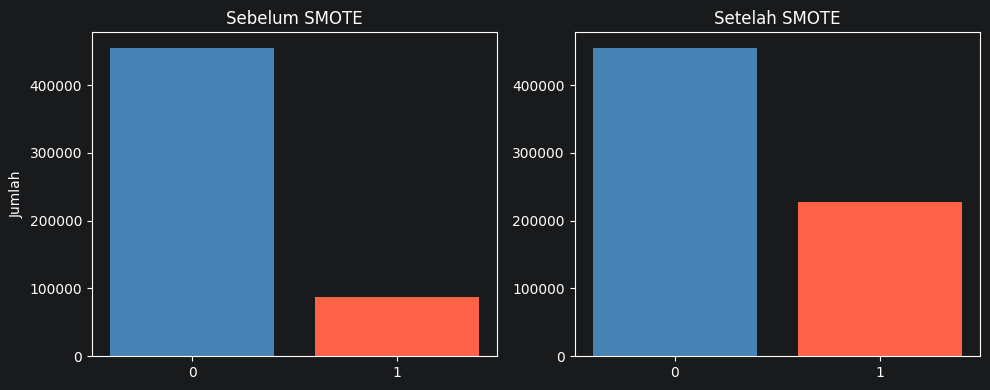

In [8]:
print("=== Sebelum SMOTE ===")
print(y.value_counts())

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\n=== Setelah SMOTE ===")
unique, counts = np.unique(y_resampled, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Kelas {u}: {c:,}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['0', '1'], [sum(y==0), sum(y==1)], color=['steelblue', 'tomato'])
axes[0].set_title('Sebelum SMOTE')
axes[0].set_ylabel('Jumlah')
axes[1].bar(['0', '1'], [sum(y_resampled==0), sum(y_resampled==1)], color=['steelblue', 'tomato'])
axes[1].set_title('Setelah SMOTE')
plt.tight_layout()
plt.show()


## 8. Scaling Fitur Numerik

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)
X_scaled = pd.DataFrame(X_scaled, columns=X_resampled.columns)
print("=== Statistik setelah scaling ===")
print(X_scaled.describe().round(3))


=== Statistik setelah scaling ===
       suitability_score  stress_level  ph_stress_flag  thermal_regime  \
count         682695.000    682695.000      682695.000      682695.000   
mean               0.000         0.000          -0.000           0.000   
std                1.000         1.000           1.000           1.000   
min               -1.997        -1.423          -0.664          -2.533   
25%               -0.872        -1.423          -0.664          -0.960   
50%               -0.072        -0.153          -0.664           0.614   
75%                0.794         1.116           1.506           0.614   
max                1.705         1.116           1.506           0.614   

       soil_temp_c  moisture_regime  air_temp_c  nutrient_balance  \
count   682695.000       682695.000  682695.000        682695.000   
mean         0.000           -0.000      -0.000            -0.000   
std          1.000            1.000       1.000             1.000   
min         -2.924     

## 9. Simpan Hasil Preprocessing

In [10]:
import os
os.makedirs('../output', exist_ok=True)

# Simpan data hasil preprocessing
X_scaled['failure_flag'] = y_resampled.values
X_scaled.to_csv('../dataset/data_cleaned.csv', index=False)
print("Data cleaned disimpan ke: ../dataset/data_cleaned.csv")
print("Shape final:", X_scaled.shape)

# Simpan scaler dan label encoders untuk digunakan di notebook 3
joblib.dump(scaler, '../output/scaler.pkl')
joblib.dump(le_dict, '../output/label_encoders.pkl')
joblib.dump(selected_features, '../output/selected_features.pkl')
print("Scaler, label encoders, dan selected features disimpan.")


Data cleaned disimpan ke: ../output/data_cleaned.csv
Shape final: (682695, 19)
Scaler, label encoders, dan selected features disimpan.


## ✅ Ringkasan Cleaning
- Drop kolom `location_id` (ID unik tidak informatif untuk model)
- Tidak ada duplikat & missing values pada dataset ini
- Label Encoding diterapkan pada semua kolom kategorikal
- Fitur dipilih berdasarkan korelasi minimal 0.02
- SMOTE digunakan untuk mengatasi imbalanced dataset
- StandardScaler diterapkan untuk normalisasi fitur numerik
